In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [ ]:
!unzip /content/images.zip -d /content/images/

Streaming output truncated to the last 5000 lines.
  inflating: /content/images/images/train/active/9709.jpg  
  inflating: /content/images/images/train/active/9714.jpg  
  inflating: /content/images/images/train/active/9740.jpg  
  inflating: /content/images/images/train/active/9744.jpg  
  inflating: /content/images/images/train/active/9762.jpg  
  inflating: /content/images/images/train/active/9764.jpg  
  inflating: /content/images/images/train/active/9766.jpg  
  inflating: /content/images/images/train/active/9772.jpg  
  inflating: /content/images/images/train/active/9775.jpg  
  inflating: /content/images/images/train/active/9778.jpg  
  inflating: /content/images/images/train/active/9779.jpg  
  inflating: /content/images/images/train/active/9783.jpg  
  inflating: /content/images/images/train/active/9790.jpg  
  inflating: /content/images/images/train/active/981.jpg  
  inflating: /content/images/images/train/active/9812.jpg  
  inflating: /content/images/images/train/active/9

# Data Cleaning & Analysis

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters

IMG_SIZE = 224
batch_size = 32

# Data Augmentations

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Custom Dataset

class FatigueDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.classes = ["active", "fatigue"]  # 0: active, 1: fatigue

        for label, class_name in enumerate(self.classes):
            folder_path = os.path.join(root_dir, class_name)
            if not os.path.exists(folder_path):
                raise FileNotFoundError(f"Folder not found: {folder_path}")

            for img_name in os.listdir(folder_path):
                if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(folder_path, img_name)
                    self.images.append(img_path)
                    self.labels.append(label)

        print(f"Loaded {len(self.images)} images from {root_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        else:
            image = test_transforms(image)

        return image, torch.tensor(label, dtype=torch.long)

# Create Datasets

train_dataset = FatigueDataset(
    root_dir="/content/images/images/train",
    transform=train_transforms
)

test_dataset = FatigueDataset(
    root_dir="/content/images/images/test",
    transform=test_transforms
)

# DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Preprocessing completed")

Loaded 12102 images from /content/images/images/train
Loaded 2964 images from /content/images/images/test
Preprocessing completed


# Model Design

In [ ]:
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

def get_model(device, num_classes=2):
    weights = EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)

    num_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.7, inplace=True),
        nn.Linear(num_features, 512),
        nn.BatchNorm1d(512),
        nn.GELU(),
        nn.Dropout(p=0.7, inplace=True),
        nn.Linear(512, num_classes)
    )

    return model.to(device)

# Create model

model = get_model(device, num_classes=2)
print(model)
print("\nModel design completed")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# Model Training

In [ ]:
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Training Hyperparameters

LR = 3e-4
MAX_LR = 8e-4
EPOCHS = 25
PATIENCE = 7

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25.0,
    final_div_factor=1e4
)

# Training Loop

best_acc = 0.0
best_epoch = 0
patience_counter = 0

print("\n" + "="*60)
print("Starting training")
print("="*60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 50)

    # Training

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_dataset)
    train_acc = correct / total

    # Validation

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(test_dataset)
    val_acc = correct / total

    current_lr = optimizer.param_groups[0]['lr']
    print(f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_fatigue_detection_model.pth")
        print(f">> Saved New Best Model (Val Acc: {best_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping! No improvement for {PATIENCE} epochs.")
        break

    print()

print("\n" + "="*60)
print("Training Finished!")
print(f"Best Validation Accuracy: {best_acc:.4f} at Epoch {best_epoch}")
print("="*60)


Starting training

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 93/93 [00:06<00:00, 14.85it/s]


LR: 6.52e-05 | Train Loss: 0.7184 | Train Acc: 0.5926 | Val Loss: 0.5545 | Val Acc: 0.7321
>> Saved New Best Model (Val Acc: 0.7321)


Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 93/93 [00:06<00:00, 14.10it/s]


LR: 1.59e-04 | Train Loss: 0.5384 | Train Acc: 0.7698 | Val Loss: 0.3891 | Val Acc: 0.8829
>> Saved New Best Model (Val Acc: 0.8829)


Epoch 3/25
--------------------------------------------------


...

LR: 2.54e-05 | Train Loss: 0.2349 | Train Acc: 0.9850 | Val Loss: 0.2888 | Val Acc: 0.9507


Epoch 24/25
--------------------------------------------------


Validation: 100%|██████████| 93/93 [00:06<00:00, 13.73it/s]


LR: 6.40e-06 | Train Loss: 0.2365 | Train Acc: 0.9836 | Val Loss: 0.2895 | Val Acc: 0.9504


Epoch 25/25
--------------------------------------------------


Validation: 100%|██████████| 93/93 [00:06<00:00, 13.55it/s]

LR: 3.24e-09 | Train Loss: 0.2334 | Train Acc: 0.9855 | Val Loss: 0.2860 | Val Acc: 0.9528

Early Stopping! No improvement for 7 epochs.

Training Finished!
Best Validation Accuracy: 0.9534 at Epoch 18


# Model Testing & Inference

Loaded the best saved model for evaluation.


Evaluating on Test Set: 100%|██████████| 93/93 [00:06<00:00, 13.93it/s]


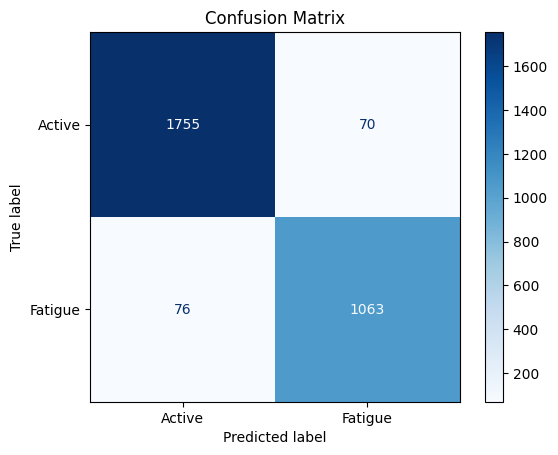


Classification Report :
              precision    recall  f1-score   support

      Active     0.9585    0.9616    0.9601      1825
     Fatigue     0.9382    0.9333    0.9357      1139

    accuracy                         0.9507      2964
   macro avg     0.9484    0.9475    0.9479      2964
weighted avg     0.9507    0.9507    0.9507      2964



In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


model.eval()
model.load_state_dict(torch.load("best_fatigue_detection_model.pth"))
print("Loaded the best saved model for evaluation.")

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


# ConfusionMatrix

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Fatigue'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Classification Report (Precision, Recall, F1 Score)

print("\nClassification Report :")
print(classification_report(all_labels, all_preds,
                            target_names=['Active', 'Fatigue'],
                            digits=4))

Best model loaded successfully!

Please upload an image from your device...


Saving m.png to m (1).png

Uploaded image: m (1).png


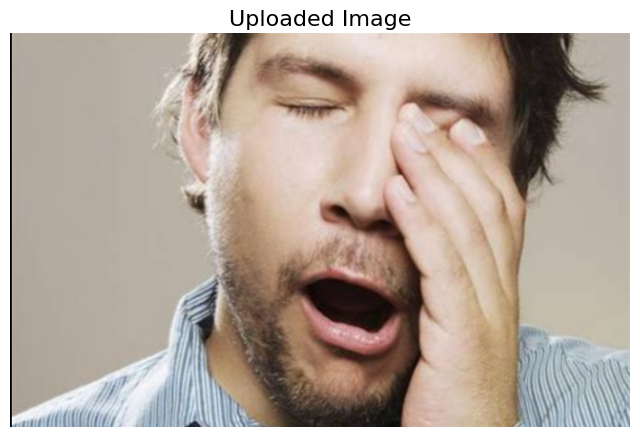


Prediction : Fatigue
Confidence : 93.71%

Class Probabilities :
Active: 6.29%  █
Fatigue: 93.71%  ██████████████████


In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from google.colab import files
import io

# Load the best saved model

model.load_state_dict(torch.load("best_fatigue_detection_model.pth"))
model.eval()
print("Best model loaded successfully!")

# Image transformations for inference

inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class_names = ['Active', 'Fatigue']
print("\nPlease upload an image from your device...")

# Upload image

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nUploaded image: {filename}")


    img_bytes = uploaded[filename]
    image = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # Display the original image

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Uploaded Image", fontsize=16)
    plt.show()

    # Prepare the image for the model

    input_tensor = inference_transforms(image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Prediction

    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, predicted_class = torch.max(probabilities, 0)


    predicted_label = class_names[predicted_class.item()]
    confidence_percent = confidence.item() * 100

    print(f"\nPrediction : {predicted_label}")
    print(f"Confidence : {confidence_percent:.2f}%")

    # Display probability for each class

    print("\nClass Probabilities :")
    for i, name in enumerate(class_names):
        prob = probabilities[i].item() * 100
        bar = '█' * int(prob // 5)
        print(f"{name}: {prob:.2f}%  {bar}")